# Day 06 — Sales Prediction Mini Project

ဒီနေ့မှာ CSV dataset ဖတ်ခြင်းကနေ Model သိမ်းခြင်းအထိ ML workflow အပြည့်အစုံကို လုပ်ပါမယ်။

## 1. Libraries Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

`joblib` မရှိရင်—

```python
!pip install joblib
```

## 2. Sample Dataset တည်ဆောက်ခြင်း

ဒီ Project မှာ Sales ကို အချက်သုံးခုနဲ့ ခန့်မှန်းပါမယ်။

- `advertising_lakh` — ကြော်ငြာအသုံးစရိတ်
- `visitors` — ဆိုင်/Website လာရောက်သူ
- `discount_percent` — Discount ရာခိုင်နှုန်း
- `sales_lakh` — ခန့်မှန်းလိုသော Sales

In [2]:
np.random.seed(42)

rows = 50

advertising = np.random.randint(5, 51, rows)
visitors = np.random.randint(100, 1001, rows)
discount = np.random.randint(0, 21, rows)
noise = np.random.normal(0, 3, rows)

sales = (
    0.8 * advertising
    + 0.05 * visitors
    + 0.6 * discount
    + noise
)

df = pd.DataFrame({
    "advertising_lakh": advertising,
    "visitors": visitors,
    "discount_percent": discount,
    "sales_lakh": sales.round(2)
})

df.head()

,advertising_lakh,visitors,discount_percent,sales_lakh
0,43,466,0,56.10
1,33,554,6,53.21
2,19,527,8,43.98
3,47,608,0,70.23
4,12,875,11,59.31


## 3. CSV File အဖြစ်သိမ်းခြင်း

In [3]:
df.to_csv("sales_data.csv", index=False)

print("sales_data.csv created successfully.")

sales_data.csv created successfully.


ပြီးရင် CSV ကို ပြန်ဖတ်ပါ။

In [4]:
df = pd.read_csv("sales_data.csv")

df.head()

,advertising_lakh,visitors,discount_percent,sales_lakh
0,43,466,0,56.10
1,33,554,6,53.21
2,19,527,8,43.98
3,47,608,0,70.23
4,12,875,11,59.31


ဒါက လက်တွေ့ Project တွေမှာ အသုံးပြုမယ့် workflow ဖြစ်ပါတယ်—

```
Database/Excel → CSV → Pandas → ML Model
```

## 4. Dataset စစ်ဆေးခြင်း

In [5]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nStatistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (50, 4)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   advertising_lakh  50 non-null     int64  
 1   visitors          50 non-null     int64  
 2   discount_percent  50 non-null     int64  
 3   sales_lakh        50 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 1.7 KB

Statistics:


,advertising_lakh,visitors,discount_percent,sales_lakh
count,50.000000,50.000000,50.000000,50.000000
mean,26.760000,559.160000,7.380000,53.525400
std,12.846917,272.459048,5.465625,16.499431
min,6.000000,101.000000,0.000000,19.210000
25%,16.500000,324.750000,2.250000,41.670000
50%,26.500000,554.500000,7.000000,52.650000
75%,36.250000,825.500000,11.000000,65.982500
max,48.000000,978.000000,19.000000,88.370000



Missing values:
advertising_lakh    0
visitors            0
discount_percent    0
sales_lakh          0
dtype: int64

Duplicate rows:
0


Missing value ရှိရင်—

```python
df = df.dropna()
```

Duplicate ရှိရင်—

```python
df = df.drop_duplicates()
```

လက်ရှိ sample data မှာတော့ မရှိသင့်ပါဘူး။

## 5. Feature နှင့် Target ခွဲခြင်း

In [6]:
feature_columns = [
    "advertising_lakh",
    "visitors",
    "discount_percent"
]

X = df[feature_columns]
y = df["sales_lakh"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,advertising_lakh,visitors,discount_percent
0,43,466,0
1,33,554,6
2,19,527,8
3,47,608,0
4,12,875,11


Target:


0    56.10
1    53.21
2    43.98
3    70.23
4    59.31
Name: sales_lakh, dtype: float64

Day 04–05 မှာ Feature တစ်ခုသာ အသုံးပြုခဲ့ပါတယ်။ အခု Feature သုံးခုသုံးထားလို့ `Multiple Linear Regression` လို့ခေါ်ပါတယ်။

Equation က—

\[
Sales = b_0 + b_1(Advertising) + b_2(Visitors) + b_3(Discount)
\]

ဖြစ်ပါတယ်။

## 6. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 40
Testing rows: 10


ရလဒ်က—

```
Training rows: 40
Testing rows: 10
```

ဖြစ်ရပါမယ်။

## 7. Model Training

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 8. Model Evaluation

In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f} lakh")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} lakh")
print(f"R² Score: {r2:.4f}")

MAE: 2.4754 lakh
MSE: 8.7571
RMSE: 2.9592 lakh
R² Score: 0.9743


ဒီ Dataset မှာ noise ထည့်ထားတာကြောင့် prediction ဟာ အပြည့်အဝတိကျမှာ မဟုတ်ပါဘူး။ ဒါက real-world data နဲ့ ပိုနီးစပ်စေပါတယ်။

## 9. Actual နှင့် Predicted နှိုင်းယှဉ်ခြင်း

In [10]:
results = X_test.copy()

results["actual_sales"] = y_test
results["predicted_sales"] = y_pred.round(2)

results["error"] = (
    results["actual_sales"]
    - results["predicted_sales"]
).round(2)

results

,advertising_lakh,visitors,discount_percent,actual_sales,predicted_sales,error
13,44,665,4,72.87,70.33,2.54
39,13,152,8,21.54,22.72,-1.18
30,46,826,2,76.08,78.73,-2.65
45,13,592,6,45.92,43.54,2.38
17,6,576,6,36.32,37.23,-0.91
48,24,114,3,30.92,26.35,4.57
26,26,915,11,70.32,73.07,-2.75
25,16,962,2,56.03,61.96,-5.93
32,20,801,14,64.76,64.50,0.26
19,48,501,7,68.69,67.11,1.58


## 10. Coefficients စစ်ဆေးခြင်း

Feature တစ်ခုစီက Sales ပေါ် ဘယ်လောက်သက်ရောက်သလဲ ကြည့်ပါမယ်။

In [11]:
coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.coef_
})

print("Intercept:", model.intercept_)

coefficients

Intercept: -0.10102927066109402


,feature,coefficient
0,advertising_lakh,0.786146
1,visitors,0.050148
2,discount_percent,0.621973


Coefficient အဓိပ္ပာယ်ဥပမာ—

- Advertising coefficient `0.8` နီးပါးဆိုရင် Advertising တစ်သိန်ကျပ်တိုးတိုင်း Sales က `0.8 သိန်း` နီးပါးတိုးနိုင်ပါတယ်။
- Visitors coefficient `0.05` ဆိုရင် Visitor တစ်ယောက်တိုးတိုင်း Sales က `0.05 သိန်း` တိုးတဲ့ pattern ကို Model သင်ယူထားတာပါ။
- ဒါဟာ အခြား Feature တွေ မပြောင်းဘူးလို့ ယူဆထားတဲ့ သက်ရောက်မှုဖြစ်ပါတယ်။

## 11. Sales အသစ်ခန့်မှန်းခြင်း

အောက်ပါအခြေအနေကို ခန့်မှန်းပါမယ်။

- Advertising — 30 သိန်း
- Visitors — 700
- Discount — 10%

In [12]:
new_data = pd.DataFrame({
    "advertising_lakh": [30],
    "visitors": [700],
    "discount_percent": [10]
})

predicted_sales = model.predict(new_data)

print(
    f"Predicted Sales: "
    f"{predicted_sales[0]:.2f} lakh MMK"
)

Predicted Sales: 64.81 lakh MMK


Scenario အများကြီးကို တစ်ခါတည်းခန့်မှန်းနိုင်ပါတယ်။

In [13]:
scenarios = pd.DataFrame({
    "advertising_lakh": [10, 20, 30, 40],
    "visitors": [200, 400, 700, 900],
    "discount_percent": [0, 5, 10, 15]
})

scenarios["predicted_sales_lakh"] = (
    model.predict(scenarios).round(2)
)

scenarios

,advertising_lakh,visitors,discount_percent,predicted_sales_lakh
0,10,200,0,17.79
1,20,400,5,38.79
2,30,700,10,64.81
3,40,900,15,85.81


## 12. Actual vs Predicted Graph

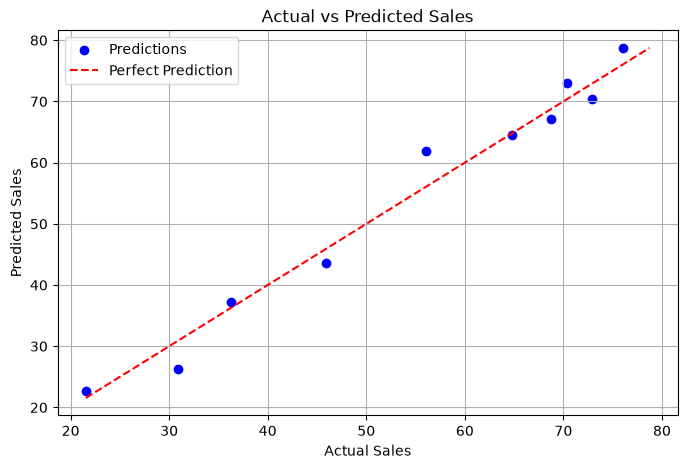

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    color="blue",
    label="Predictions"
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()

အစက်တွေက အနီရောင် dashed line နားကပ်လေလေ Model ကောင်းလေလေ ဖြစ်ပါတယ်။

## 13. Model ကို File အဖြစ်သိမ်းခြင်း

Training ပြီးသား Model ကို application ထဲမှာ အသုံးပြုနိုင်အောင် သိမ်းပါမယ်။

In [15]:
joblib.dump(model, "sales_prediction_model.pkl")

print("Model saved successfully.")

Model saved successfully.


ပြန်ဖွင့်ပြီး အသုံးပြုခြင်း—

In [16]:
loaded_model = joblib.load(
    "sales_prediction_model.pkl"
)

test_data = pd.DataFrame({
    "advertising_lakh": [25],
    "visitors": [500],
    "discount_percent": [8]
})

result = loaded_model.predict(test_data)

print(f"Loaded model prediction: {result[0]:.2f} lakh MMK")

Loaded model prediction: 49.60 lakh MMK


ဒီအဆင့်မှာ `day06.ipynb` နဲ့အတူ—

```
sales_data.csv
sales_prediction_model.pkl
```

ဆိုတဲ့ File နှစ်ခု ထပ်ရလာပါမယ်။